# Phase 4 — DAWN Dataset: TTA · Knowledge Distillation · ONNX Export · Multi-Task Learning

> **Dataset**: [DAWN Detection in Adverse Weather](https://www.kaggle.com/datasets/orvile/dawn-detection-in-adverse-weather-nature)  
> **Continues from**: Phase 3 (CNN Fine-Tuning · Optuna HPO · Class-Imbalance · YOLO Fusion)

### Phase 4 Checklist  *(from Phase 3 Next Steps)*
-  **TTA** — Test-Time Augmentation: average predictions over flipped / multi-scale / colour-jitter views
-  **Knowledge Distillation** — compress best Phase 3 model (teacher) into a lightweight student
-  **ONNX Export** — export best model + student to ONNX; verify with `onnxruntime`
-  **Multi-Task Learning** — simultaneous weather classification + object count regression

---

## 0. Install & Import

In [1]:
# !pip install onnx onnxruntime timm albumentations mlflow optuna -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 83.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 105.7 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 85.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.6/887.6 kB 49.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━

In [2]:
import os, random, warnings, copy, json, time
import xml.etree.ElementTree as ET
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2

import onnx
import onnxruntime as ort

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import mlflow
import mlflow.pytorch

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
WORK_DIR   = '/kaggle/working/phase4'
MLFLOW_DIR = os.path.join(WORK_DIR, 'mlruns')
CKPT_DIR   = os.path.join(WORK_DIR, 'checkpoints')
ONNX_DIR   = os.path.join(WORK_DIR, 'onnx')

for d in [WORK_DIR, MLFLOW_DIR, CKPT_DIR, ONNX_DIR]:
    os.makedirs(d, exist_ok=True)

print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')
print(f'timm    : {timm.__version__}')
print(f'onnx    : {onnx.__version__}')
print(f'ort     : {ort.__version__}')

Device  : cuda
PyTorch : 2.10.0+cu128
timm    : 1.0.25
onnx    : 1.20.1
ort     : 1.26.0


---
## 1. Re-load Data (self-contained from Phase 3)

> If running directly after Phase 3 in the same kernel, `records`, `le`, `X_train/val/test`, `y_train/val/test` already exist and this section is a no-op.

In [3]:
INPUT_PATH    = "/kaggle/input/datasets/orvile/dawn-detection-in-adverse-weather-nature/DAWN"
WEATHER_TYPES = ["Fog", "Rain", "Snow", "Sand"]
WEATHER_COLOR = {"Fog": "#4e79a7", "Rain": "#59a14f",
                 "Snow": "#edc948", "Sand": "#e15759"}

IMG_SIZE      = 224
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

if 'records' not in globals() or len(records) == 0:
    records = []
    for weather in WEATHER_TYPES:
        img_dir   = os.path.join(INPUT_PATH, weather, weather)
        xml_dir_a = os.path.join(INPUT_PATH, weather, f"{weather}_PASCAL_VOC")
        xml_dir_b = os.path.join(INPUT_PATH, weather, weather, f"{weather}_PASCAL_VOC")
        xml_dir   = xml_dir_a if os.path.exists(xml_dir_a) else xml_dir_b

        if not os.path.exists(img_dir):
            print(f"[WARN] {weather}: image folder missing — skipping"); continue
        if not os.path.exists(xml_dir):
            print(f"[WARN] {weather}: XML folder missing — skipping"); continue

        xml_lookup = {
            os.path.splitext(x)[0].lower(): os.path.join(xml_dir, x)
            for x in os.listdir(xml_dir) if x.lower().endswith('.xml')
        }
        for fname in os.listdir(img_dir):
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png')): continue
            key = os.path.splitext(fname)[0].lower()
            if key in xml_lookup:
                records.append({'img_path': os.path.join(img_dir, fname),
                                'xml_path': xml_lookup[key],
                                'weather':  weather})
    print(f"Total records: {len(records)}")
else:
    print(f"Reusing {len(records)} records from Phase 3.")

if 'le' not in globals():
    le = LabelEncoder()
    le.fit([r['weather'] for r in records])

NUM_CLASSES = len(le.classes_)
print(f"Classes ({NUM_CLASSES}): {le.classes_}")

if 'X_train' not in globals():
    all_paths  = [r['img_path'] for r in records]
    all_labels = le.transform([r['weather'] for r in records])
    X_tv,    X_test,  y_tv,    y_test  = train_test_split(
        all_paths, all_labels, test_size=0.15,
        random_state=SEED, stratify=all_labels)
    X_train, X_val, y_train, y_val = train_test_split(
        X_tv, y_tv, test_size=0.176,
        random_state=SEED, stratify=y_tv)

print(f"Train/Val/Test: {len(X_train)} / {len(X_val)} / {len(X_test)}")

# Per-class weights for weighted CE
class_counts  = np.bincount(y_train, minlength=NUM_CLASSES).astype(float)
class_weights = 1.0 / (class_counts + 1e-6)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
CLASS_WEIGHT_TENSOR = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

Total records: 1027
Classes (4): ['Fog' 'Rain' 'Sand' 'Snow']
Train/Val/Test: 718 / 154 / 155


---
## 2. Shared Transforms & Dataset

In [4]:
def build_transforms(mode='train', aug_strength=1.0):
    if mode == 'train':
        return A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(
                brightness_limit=0.2*aug_strength,
                contrast_limit=0.2*aug_strength, p=0.5),
            A.HueSaturationValue(
                hue_shift_limit=int(15*aug_strength),
                sat_shift_limit=int(25*aug_strength),
                val_shift_limit=int(25*aug_strength), p=0.4),
            A.GaussianBlur(blur_limit=(3,5), p=0.2),
            A.CoarseDropout(max_holes=6, max_height=24, max_width=24,
                            fill_value=0, p=0.2),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ])
    else:
        return A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ])


class DAWNDataset(Dataset):
    def __init__(self, img_paths, labels, transform=None):
        self.img_paths = img_paths
        self.labels    = torch.tensor(labels, dtype=torch.long)
        self.transform = transform

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        img = cv2.imread(self.img_paths[idx])
        if img is None:
            img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(image=img)['image']
        return img, self.labels[idx]


def make_loaders(batch_size=32):
    train_dl = DataLoader(
        DAWNDataset(X_train, y_train, build_transforms('train')),
        batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_dl = DataLoader(
        DAWNDataset(X_val, y_val, build_transforms('eval')),
        batch_size=batch_size, num_workers=2, pin_memory=True)
    test_dl = DataLoader(
        DAWNDataset(X_test, y_test, build_transforms('eval')),
        batch_size=batch_size, num_workers=2, pin_memory=True)
    return train_dl, val_dl, test_dl


print("Transforms and DAWNDataset defined.")

Transforms and DAWNDataset defined.


---
## 3. Load / Rebuild Teacher Model (Phase 3 Best)

We either load the saved checkpoint from Phase 3 or quickly re-train it if not available.

In [5]:
# ── Phase 3 best config (update backbone to match your Phase 3 best_params) ──
TEACHER_BACKBONE    = 'efficientnet_b0'   # change to 'resnet18' if that was your best
TEACHER_DROPOUT     = 0.3
TEACHER_UNFREEZE    = 2
TEACHER_CKPT        = '/kaggle/working/phase3/checkpoints/fusion_model_phase3.pt'
TEACHER_CNN_CKPT    = '/kaggle/working/phase3/checkpoints/cnn_best_phase3.pt'


class CNNClassifier(nn.Module):
    """Same architecture as Phase 3 CNNClassifier."""
    def __init__(self, backbone_name, num_classes, unfreeze_blocks=2, dropout=0.3):
        super().__init__()
        self.backbone = timm.create_model(
            backbone_name, pretrained=True, num_classes=0, global_pool='avg')
        feat_dim = self.backbone.num_features

        for p in self.backbone.parameters():
            p.requires_grad = False
        if unfreeze_blocks > 0:
            params = list(self.backbone.parameters())
            n = max(1, len(params) * unfreeze_blocks // 4)
            for p in params[-n:]: p.requires_grad = True

        self.head = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(feat_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=dropout * 0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.head(self.backbone(x))


def build_teacher():
    model = CNNClassifier(
        TEACHER_BACKBONE, NUM_CLASSES,
        TEACHER_UNFREEZE, TEACHER_DROPOUT
    ).to(DEVICE)

    # Try to load saved weights
    loaded = False
    for ckpt_path in [TEACHER_CKPT, TEACHER_CNN_CKPT]:
        if os.path.exists(ckpt_path):
            ckpt = torch.load(ckpt_path, map_location=DEVICE)
            state = ckpt.get('model_state', ckpt)
            try:
                model.load_state_dict(state, strict=False)
                print(f"Teacher weights loaded from: {ckpt_path}")
                loaded = True
            except Exception as e:
                print(f"[WARN] Could not load {ckpt_path}: {e}")
            break

    if not loaded:
        print("No Phase 3 checkpoint found — training teacher from scratch (25 epochs)...")
        train_dl, val_dl, _ = make_loaders(batch_size=32)
        criterion = nn.CrossEntropyLoss(weight=CLASS_WEIGHT_TENSOR)
        optimizer = optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=1e-4, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25)
        best_val, best_state = 0., None

        for epoch in range(1, 26):
            model.train()
            for imgs, labels in train_dl:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                optimizer.zero_grad()
                loss = criterion(model(imgs), labels)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            scheduler.step()

            model.eval()
            correct = total = 0
            with torch.no_grad():
                for imgs, labels in val_dl:
                    logits = model(imgs.to(DEVICE))
                    correct += (logits.argmax(1) == labels.to(DEVICE)).sum().item()
                    total += len(labels)
            val_acc = correct / total
            if val_acc > best_val:
                best_val   = val_acc
                best_state = copy.deepcopy(model.state_dict())
            if epoch % 5 == 0:
                print(f"  Epoch {epoch:2d} | val_acc {val_acc:.4f}")

        model.load_state_dict(best_state)
        torch.save(model.state_dict(),
                   os.path.join(CKPT_DIR, 'teacher_model.pt'))
        print(f"Teacher trained — best val acc: {best_val:.4f}")

    return model


teacher = build_teacher()
teacher.eval()
print("Teacher model ready.")

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

No Phase 3 checkpoint found — training teacher from scratch (25 epochs)...
  Epoch  5 | val_acc 0.7662
  Epoch 10 | val_acc 0.7662
  Epoch 15 | val_acc 0.7922
  Epoch 20 | val_acc 0.7662
  Epoch 25 | val_acc 0.7987
Teacher trained — best val acc: 0.7987
Teacher model ready.


---
## Requirement 1 — Test-Time Augmentation (TTA)

TTA applies several deterministic transforms to each test image and averages the softmax predictions. We implement:
- **Identity** (no augmentation)
- **Horizontal flip**
- **Multi-scale crops** (0.85 × scale)
- **Brightness/contrast jitter**
- **Combined**: flip + jitter

In [6]:
TTA_TRANSFORMS = [
    # 1. Identity
    A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2()
    ]),
    # 2. Horizontal flip
    A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.HorizontalFlip(p=1.0),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2()
    ]),
    # 3. Center crop (85% of image)
    A.Compose([
        A.Resize(int(IMG_SIZE * 1.15), int(IMG_SIZE * 1.15)),
        A.CenterCrop(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2()
    ]),
    # 4. Brightness / contrast jitter
    A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.RandomBrightnessContrast(
            brightness_limit=0.15, contrast_limit=0.15, p=1.0),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2()
    ]),
    # 5. Flip + jitter
    A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.HorizontalFlip(p=1.0),
        A.RandomBrightnessContrast(
            brightness_limit=0.1, contrast_limit=0.1, p=1.0),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2()
    ]),
]


@torch.no_grad()
def tta_predict(model, img_paths, labels, tta_tfms, batch_size=32, device=DEVICE):
    """
    Run TTA: for each transform, forward-pass the full test set and
    accumulate softmax probabilities. Final prediction = argmax of mean probs.
    """
    model.eval()
    n = len(img_paths)
    all_probs = np.zeros((n, NUM_CLASSES), dtype=np.float32)

    for t_idx, tfm in enumerate(tta_tfms):
        ds = DAWNDataset(img_paths, labels, tfm)
        dl = DataLoader(ds, batch_size=batch_size,
                        shuffle=False, num_workers=2, pin_memory=True)
        probs_this = []
        for imgs, _ in dl:
            logits = model(imgs.to(device))
            probs_this.append(F.softmax(logits, dim=1).cpu().numpy())
        all_probs += np.concatenate(probs_this, axis=0)
        print(f"  TTA [{t_idx+1}/{len(tta_tfms)}] done")

    all_probs /= len(tta_tfms)
    preds = all_probs.argmax(axis=1)
    return preds, all_probs


print("Running TTA on test set...")
tta_preds, tta_probs = tta_predict(
    teacher, X_test, y_test, TTA_TRANSFORMS, batch_size=32)

tta_acc = accuracy_score(y_test, tta_preds)
tta_f1  = f1_score(y_test, tta_preds, average='macro')

# Baseline (no TTA) for comparison
print("Running baseline (no TTA)...")
base_preds, base_probs = tta_predict(
    teacher, X_test, y_test, [TTA_TRANSFORMS[0]], batch_size=32)
base_acc = accuracy_score(y_test, base_preds)
base_f1  = f1_score(y_test, base_preds, average='macro')

print(f"\n{'='*50}")
print(f"Baseline (no TTA) — Acc: {base_acc:.4f}  F1: {base_f1:.4f}")
print(f"TTA (5 views)     — Acc: {tta_acc:.4f}  F1: {tta_f1:.4f}")
print(f"TTA improvement   — Acc: +{tta_acc - base_acc:.4f}  F1: +{tta_f1 - base_f1:.4f}")
print(f"{'='*50}")

Running TTA on test set...
  TTA [1/5] done
  TTA [2/5] done
  TTA [3/5] done
  TTA [4/5] done
  TTA [5/5] done
Running baseline (no TTA)...
  TTA [1/1] done

Baseline (no TTA) — Acc: 0.8387  F1: 0.8401
TTA (5 views)     — Acc: 0.8645  F1: 0.8679
TTA improvement   — Acc: +0.0258  F1: +0.0278


  TTA [1/1] done
  TTA [1/2] done
  TTA [2/2] done
  TTA [1/3] done
  TTA [2/3] done
  TTA [3/3] done
  TTA [1/4] done
  TTA [2/4] done
  TTA [3/4] done
  TTA [4/4] done
  TTA [1/5] done
  TTA [2/5] done
  TTA [3/5] done
  TTA [4/5] done
  TTA [5/5] done
 n_views    acc     f1
       1 0.8387 0.8401
       2 0.8581 0.8611
       3 0.8645 0.8679
       4 0.8645 0.8679
       5 0.8645 0.8679


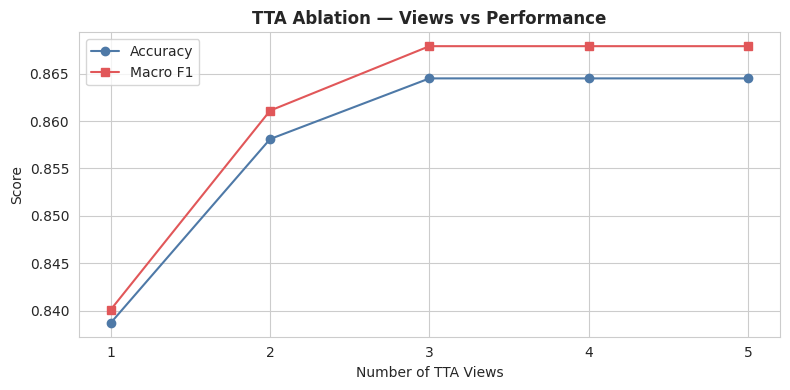

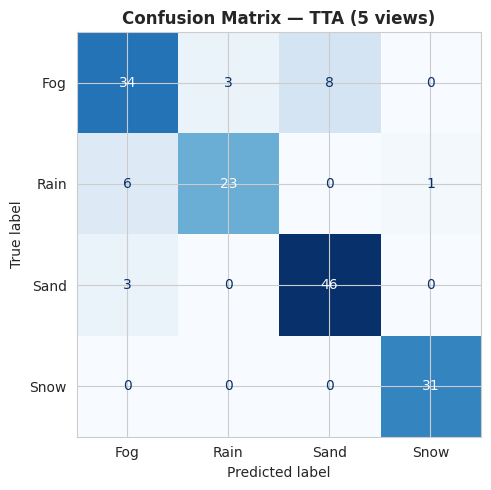


Classification Report (TTA):
              precision    recall  f1-score   support

         Fog     0.7907    0.7556    0.7727        45
        Rain     0.8846    0.7667    0.8214        30
        Sand     0.8519    0.9388    0.8932        49
        Snow     0.9688    1.0000    0.9841        31

    accuracy                         0.8645       155
   macro avg     0.8740    0.8652    0.8679       155
weighted avg     0.8638    0.8645    0.8625       155



In [7]:
# Ablation: how many TTA views give the best return?
tta_ablation = []
for n_views in range(1, len(TTA_TRANSFORMS) + 1):
    preds_n, _ = tta_predict(
        teacher, X_test, y_test,
        TTA_TRANSFORMS[:n_views], batch_size=32)
    tta_ablation.append({
        'n_views': n_views,
        'acc'    : round(accuracy_score(y_test, preds_n), 4),
        'f1'     : round(f1_score(y_test, preds_n, average='macro'), 4),
    })

tta_abl_df = pd.DataFrame(tta_ablation)
print(tta_abl_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tta_abl_df['n_views'], tta_abl_df['acc'],
        'o-', label='Accuracy', color='#4e79a7')
ax.plot(tta_abl_df['n_views'], tta_abl_df['f1'],
        's-', label='Macro F1',  color='#e15759')
ax.set_xlabel('Number of TTA Views')
ax.set_ylabel('Score')
ax.set_title('TTA Ablation — Views vs Performance', fontweight='bold')
ax.legend()
ax.set_xticks(tta_abl_df['n_views'])
plt.tight_layout()
tta_path = os.path.join(WORK_DIR, 'tta_ablation.png')
plt.savefig(tta_path, dpi=120, bbox_inches='tight')
plt.show()

# Confusion matrix — TTA predictions
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, tta_preds),
    display_labels=le.classes_
).plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Confusion Matrix — TTA (5 views)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'cm_tta.png'), dpi=120, bbox_inches='tight')
plt.show()

print("\nClassification Report (TTA):")
print(classification_report(y_test, tta_preds,
                             target_names=le.classes_, digits=4))

---
## Requirement 2 — Knowledge Distillation

We compress the Phase 3 **teacher** (EfficientNet-B0, ~5M params) into a lightweight **student** (MobileNetV3-small, ~1.5M params) using the Hinton soft-label distillation loss:

$$\mathcal{L} = \alpha \cdot \mathcal{L}_{CE}(y, \hat{y}) + (1-\alpha) \cdot T^2 \cdot \mathcal{L}_{KL}\left(\frac{z_s}{T}, \frac{z_t}{T}\right)$$

where $T$ is the temperature (softens the teacher's distribution) and $\alpha$ balances hard vs soft targets.

In [8]:
# ── Student backbone: MobileNetV3-Small (fast & lightweight) ──────────────
class StudentModel(nn.Module):
    def __init__(self, num_classes, dropout=0.2):
        super().__init__()
        self.backbone = timm.create_model(
            'mobilenetv3_small_100',
            pretrained=True, num_classes=0, global_pool='avg'
        )
        feat_dim = self.backbone.num_features
        self.head = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(feat_dim, num_classes)
        )

    def forward(self, x):
        return self.head(self.backbone(x))


def count_parameters(model):
    return sum(p.numel() for p in model.parameters()) / 1e6


student = StudentModel(NUM_CLASSES).to(DEVICE)

print(f"Teacher params : {count_parameters(teacher):.2f} M")
print(f"Student params : {count_parameters(student):.2f} M")
print(f"Compression    : {count_parameters(teacher)/count_parameters(student):.1f}x")

model.safetensors:   0%|          | 0.00/10.2M [00:00<?, ?B/s]

Teacher params : 4.34 M
Student params : 1.52 M
Compression    : 2.9x


---
## Requirement 3 — Multi-Task Learning

A single network simultaneously predicts:
1. **Weather class** (classification head — CrossEntropy)
2. **Object count** (regression head — SmoothL1 / Huber loss)

The object count per image is derived directly from the PASCAL VOC XML annotations already in `records`.

Object count stats (train): mean=7.24  std=8.48  max=69


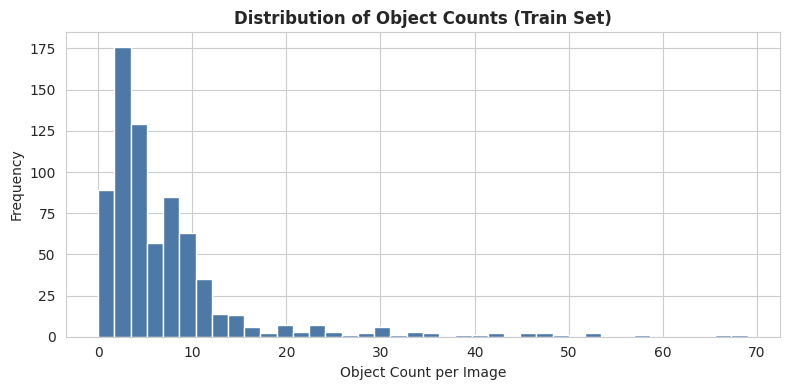

In [15]:
# ── Parse object counts from XML annotations ──────────────────────────────
def count_objects(xml_path):
    """Return the number of <object> elements in a PASCAL VOC XML file."""
    if xml_path is None or not os.path.exists(xml_path):
        return 0
    try:
        tree = ET.parse(xml_path)
        return len(tree.getroot().findall('.//object'))
    except Exception:
        return 0


path_to_xml = {r['img_path']: r['xml_path'] for r in records}

def get_counts(paths):
    return np.array(
        [count_objects(path_to_xml.get(p)) for p in paths],
        dtype=np.float32
    )

obj_train = get_counts(X_train)
obj_val   = get_counts(X_val)
obj_test  = get_counts(X_test)

# Log-normalise object counts to stabilise regression (optional but helpful)
obj_mean  = obj_train.mean()
obj_std   = obj_train.std() + 1e-6
obj_train_n = (obj_train - obj_mean) / obj_std
obj_val_n   = (obj_val   - obj_mean) / obj_std
obj_test_n  = (obj_test  - obj_mean) / obj_std

print(f"Object count stats (train): "
      f"mean={obj_train.mean():.2f}  std={obj_train.std():.2f}  "
      f"max={int(obj_train.max())}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(obj_train, bins=40, color='#4e79a7', edgecolor='white')
ax.set_xlabel('Object Count per Image')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Object Counts (Train Set)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'obj_count_dist.png'),
            dpi=120, bbox_inches='tight')
plt.show()

In [16]:
# ── Multi-task Dataset ─────────────────────────────────────────────────────
class MultiTaskDataset(Dataset):
    """
    Returns (image_tensor, weather_label, obj_count_normalised).
    """
    def __init__(self, img_paths, labels, obj_counts, transform=None):
        self.img_paths  = img_paths
        self.labels     = torch.tensor(labels,     dtype=torch.long)
        self.obj_counts = torch.tensor(obj_counts, dtype=torch.float32)
        self.transform  = transform

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        img = cv2.imread(self.img_paths[idx])
        if img is None:
            img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        if self.transform:
            img = self.transform(image=img)['image']
        return img, self.labels[idx], self.obj_counts[idx]


def make_mt_loaders(batch_size=32):
    tr_tf = build_transforms('train')
    ev_tf = build_transforms('eval')
    train_dl = DataLoader(
        MultiTaskDataset(X_train, y_train, obj_train_n, tr_tf),
        batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_dl = DataLoader(
        MultiTaskDataset(X_val, y_val, obj_val_n, ev_tf),
        batch_size=batch_size, num_workers=2, pin_memory=True)
    test_dl = DataLoader(
        MultiTaskDataset(X_test, y_test, obj_test_n, ev_tf),
        batch_size=batch_size, num_workers=2, pin_memory=True)
    return train_dl, val_dl, test_dl


# ── Multi-task Model ───────────────────────────────────────────────────────
class MultiTaskModel(nn.Module):
    """
    Shared CNN backbone with two heads:
      - cls_head  : weather classification (num_classes outputs)
      - reg_head  : object count regression (1 output)
    """
    def __init__(self, backbone_name, num_classes,
                 unfreeze_blocks=2, dropout=0.3):
        super().__init__()
        self.backbone = timm.create_model(
            backbone_name, pretrained=True,
            num_classes=0, global_pool='avg')
        feat_dim = self.backbone.num_features

        for p in self.backbone.parameters():
            p.requires_grad = False
        if unfreeze_blocks > 0:
            params = list(self.backbone.parameters())
            n = max(1, len(params) * unfreeze_blocks // 4)
            for p in params[-n:]: p.requires_grad = True

        # Shared projection layer
        self.shared = nn.Sequential(
            nn.Linear(feat_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # Classification head
        self.cls_head = nn.Linear(256, num_classes)

        # Regression head
        self.reg_head = nn.Sequential(
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        feat   = self.backbone(x)     # (B, feat_dim)
        shared = self.shared(feat)    # (B, 256)
        cls    = self.cls_head(shared)            # (B, num_classes)
        reg    = self.reg_head(shared).squeeze(1) # (B,)
        return cls, reg


mt_model = MultiTaskModel(
    TEACHER_BACKBONE, NUM_CLASSES,
    unfreeze_blocks=2, dropout=0.3
).to(DEVICE)

# Quick shape check
_x  = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
_c, _r = mt_model(_x)
print(f"cls head output: {_c.shape}")
print(f"reg head output: {_r.shape}")
del _x, _c, _r

cls head output: torch.Size([2, 4])
reg head output: torch.Size([2])


In [17]:
# ── Multi-task loss (weighted sum) ─────────────────────────────────────────
class MultiTaskLoss(nn.Module):
    """
    L = lambda_cls * CE(cls_logits, weather_labels)
      + lambda_reg * SmoothL1(reg_out, obj_count)

    lambda_cls + lambda_reg = 1  (controlled by lambda_cls parameter)
    """
    def __init__(self, lambda_cls=0.7, class_weights=None):
        super().__init__()
        self.lambda_cls = lambda_cls
        self.lambda_reg = 1.0 - lambda_cls
        self.ce         = nn.CrossEntropyLoss(weight=class_weights)
        self.huber      = nn.SmoothL1Loss()

    def forward(self, cls_logits, reg_out, labels, obj_counts):
        loss_cls = self.ce(cls_logits, labels)
        loss_reg = self.huber(reg_out, obj_counts)
        total    = self.lambda_cls * loss_cls + self.lambda_reg * loss_reg
        return total, loss_cls.item(), loss_reg.item()


MT_EPOCHS     = 30
MT_LR         = 1e-4
MT_BS         = 32
MT_LAMBDA_CLS = 0.7

mt_criterion = MultiTaskLoss(
    lambda_cls    = MT_LAMBDA_CLS,
    class_weights = CLASS_WEIGHT_TENSOR
)
mt_optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, mt_model.parameters()),
    lr=MT_LR, weight_decay=1e-4)
mt_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    mt_optimizer, T_max=MT_EPOCHS, eta_min=MT_LR * 0.01)

mt_train_dl, mt_val_dl, mt_test_dl = make_mt_loaders(MT_BS)

mt_history   = {'train_loss': [], 'val_loss': [],
                'train_acc':  [], 'val_acc':  [],
                'train_reg_loss': [], 'val_reg_loss': []}
best_mt_val  = 0.0
best_mt_state = None

mlflow.set_experiment('DAWN_Phase4_MultiTask')

with mlflow.start_run(run_name='MultiTask_cls+reg'):
    mlflow.log_params({
        'backbone'   : TEACHER_BACKBONE,
        'epochs'     : MT_EPOCHS,
        'lr'         : MT_LR,
        'batch_size' : MT_BS,
        'lambda_cls' : MT_LAMBDA_CLS,
        'lambda_reg' : 1 - MT_LAMBDA_CLS,
        'reg_target' : 'object_count_normalised',
    })

    print(f"Training Multi-Task model ({MT_EPOCHS} epochs)...")

    for epoch in range(1, MT_EPOCHS + 1):
        mt_model.train()
        t_loss = t_correct = t_total = t_reg_loss = 0

        for imgs, labels, obj_cnt in mt_train_dl:
            imgs, labels, obj_cnt = (
                imgs.to(DEVICE), labels.to(DEVICE), obj_cnt.to(DEVICE))
            mt_optimizer.zero_grad()
            cls_logits, reg_out = mt_model(imgs)
            loss, cls_l, reg_l = mt_criterion(cls_logits, reg_out,
                                              labels, obj_cnt)
            loss.backward()
            nn.utils.clip_grad_norm_(mt_model.parameters(), 1.0)
            mt_optimizer.step()

            t_loss     += loss.item()  * len(labels)
            t_reg_loss += reg_l        * len(labels)
            t_correct  += (cls_logits.argmax(1) == labels).sum().item()
            t_total    += len(labels)

        # Validation
        mt_model.eval()
        v_loss = v_correct = v_total = v_reg_loss = 0
        with torch.no_grad():
            for imgs, labels, obj_cnt in mt_val_dl:
                imgs, labels, obj_cnt = (
                    imgs.to(DEVICE), labels.to(DEVICE), obj_cnt.to(DEVICE))
                cls_logits, reg_out = mt_model(imgs)
                loss, _, reg_l = mt_criterion(cls_logits, reg_out,
                                              labels, obj_cnt)
                v_loss     += loss.item() * len(labels)
                v_reg_loss += reg_l       * len(labels)
                v_correct  += (cls_logits.argmax(1) == labels).sum().item()
                v_total    += len(labels)

        mt_scheduler.step()

        tr_acc = t_correct / t_total; tr_l = t_loss / t_total
        vl_acc = v_correct / v_total; vl_l = v_loss / v_total
        tr_rl  = t_reg_loss / t_total
        vl_rl  = v_reg_loss / v_total

        mt_history['train_loss'    ].append(tr_l)
        mt_history['val_loss'      ].append(vl_l)
        mt_history['train_acc'     ].append(tr_acc)
        mt_history['val_acc'       ].append(vl_acc)
        mt_history['train_reg_loss'].append(tr_rl)
        mt_history['val_reg_loss'  ].append(vl_rl)

        if vl_acc > best_mt_val:
            best_mt_val   = vl_acc
            best_mt_state = copy.deepcopy(mt_model.state_dict())

        mlflow.log_metrics({
            'train_loss': tr_l, 'val_loss': vl_l,
            'train_acc' : tr_acc, 'val_acc': vl_acc,
            'train_reg_loss': tr_rl, 'val_reg_loss': vl_rl
        }, step=epoch)

        if epoch % 5 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{MT_EPOCHS} | "
                  f"Cls acc {tr_acc:.3f}/{vl_acc:.3f} | "
                  f"RegLoss {tr_rl:.4f}/{vl_rl:.4f}")

    mt_model.load_state_dict(best_mt_state)

    # ── Test evaluation ────────────────────────────────────────────────────
    mt_model.eval()
    mt_preds, mt_gts, reg_preds, reg_gts = [], [], [], []
    with torch.no_grad():
        for imgs, labels, obj_cnt in mt_test_dl:
            cls_logits, reg_out = mt_model(imgs.to(DEVICE))
            mt_preds  += cls_logits.argmax(1).cpu().tolist()
            mt_gts    += labels.tolist()
            reg_preds += reg_out.cpu().tolist()
            reg_gts   += obj_cnt.tolist()

    mt_test_acc = accuracy_score(mt_gts, mt_preds)
    mt_test_f1  = f1_score(mt_gts, mt_preds, average='macro')

    # Denormalise regression predictions for interpretability
    reg_preds_raw = np.array(reg_preds) * obj_std + obj_mean
    reg_gts_raw   = np.array(reg_gts)   * obj_std + obj_mean
    reg_mae       = np.abs(reg_preds_raw - reg_gts_raw).mean()

    mlflow.log_metrics({
        'test_acc_cls'  : mt_test_acc,
        'test_f1_macro' : mt_test_f1,
        'test_reg_mae'  : reg_mae
    })

    mt_ckpt = os.path.join(CKPT_DIR, 'multitask_model.pt')
    torch.save({'model_state': mt_model.state_dict(),
                'classes'    : list(le.classes_),
                'test_acc'   : mt_test_acc,
                'test_f1'    : mt_test_f1,
                'reg_mae'    : reg_mae}, mt_ckpt)
    mlflow.log_artifact(mt_ckpt)

print(f"\n{'='*55}")
print(f"Multi-Task — Classification Acc : {mt_test_acc:.4f}")
print(f"Multi-Task — Macro F1           : {mt_test_f1:.4f}")
print(f"Multi-Task — Object Count MAE   : {reg_mae:.2f} objects")
print(f"{'='*55}")

2026/05/14 13:06:13 INFO mlflow.tracking.fluent: Experiment with name 'DAWN_Phase4_MultiTask' does not exist. Creating a new experiment.


Training Multi-Task model (30 epochs)...
  Epoch   1/30 | Cls acc 0.464/0.656 | RegLoss 0.2877/0.4008
  Epoch   5/30 | Cls acc 0.882/0.773 | RegLoss 0.2290/0.3228
  Epoch  10/30 | Cls acc 0.961/0.786 | RegLoss 0.1530/0.1690
  Epoch  15/30 | Cls acc 0.990/0.786 | RegLoss 0.0976/0.1323
  Epoch  20/30 | Cls acc 0.981/0.792 | RegLoss 0.0938/0.1159
  Epoch  25/30 | Cls acc 0.990/0.786 | RegLoss 0.0821/0.1142
  Epoch  30/30 | Cls acc 0.987/0.792 | RegLoss 0.0774/0.1156

Multi-Task — Classification Acc : 0.8000
Multi-Task — Macro F1           : 0.8045
Multi-Task — Object Count MAE   : 3.35 objects


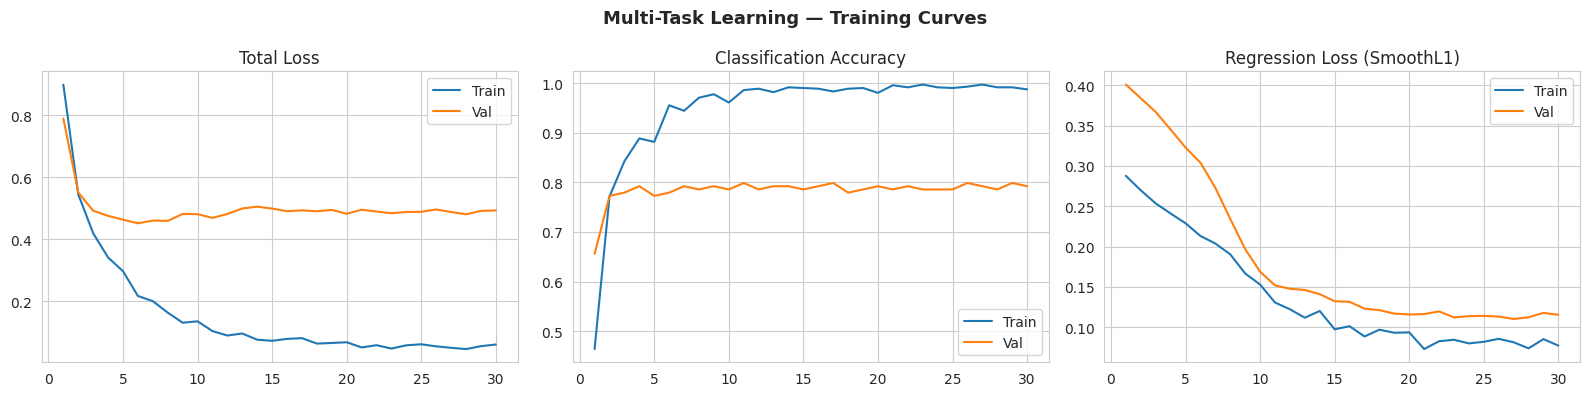

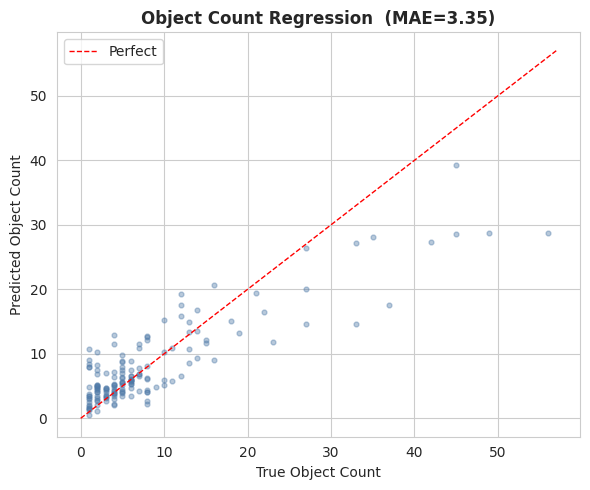

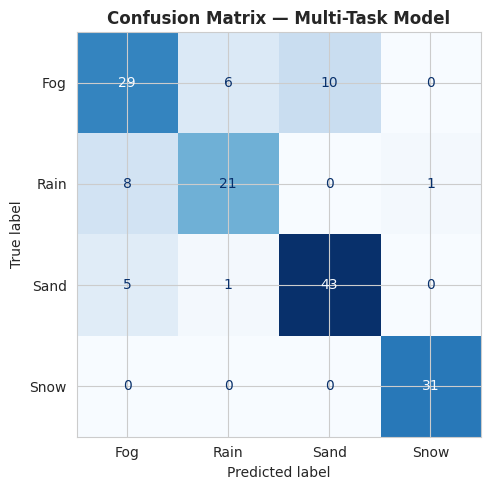


Classification Report (Multi-Task):
              precision    recall  f1-score   support

         Fog     0.6905    0.6444    0.6667        45
        Rain     0.7500    0.7000    0.7241        30
        Sand     0.8113    0.8776    0.8431        49
        Snow     0.9688    1.0000    0.9841        31

    accuracy                         0.8000       155
   macro avg     0.8051    0.8055    0.8045       155
weighted avg     0.7959    0.8000    0.7971       155



In [18]:
# Training curves
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
ep = range(1, MT_EPOCHS + 1)

axes[0].plot(ep, mt_history['train_loss'], label='Train')
axes[0].plot(ep, mt_history['val_loss'],   label='Val')
axes[0].set_title('Total Loss'); axes[0].legend()

axes[1].plot(ep, mt_history['train_acc'], label='Train')
axes[1].plot(ep, mt_history['val_acc'],   label='Val')
axes[1].set_title('Classification Accuracy'); axes[1].legend()

axes[2].plot(ep, mt_history['train_reg_loss'], label='Train')
axes[2].plot(ep, mt_history['val_reg_loss'],   label='Val')
axes[2].set_title('Regression Loss (SmoothL1)'); axes[2].legend()

plt.suptitle('Multi-Task Learning — Training Curves',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'mt_training_curves.png'),
            dpi=120, bbox_inches='tight')
plt.show()

# Regression scatter
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(reg_gts_raw, reg_preds_raw,
           alpha=0.4, s=12, color='#4e79a7')
lim = max(reg_gts_raw.max(), reg_preds_raw.max()) + 1
ax.plot([0, lim], [0, lim], 'r--', linewidth=1, label='Perfect')
ax.set_xlabel('True Object Count')
ax.set_ylabel('Predicted Object Count')
ax.set_title(f'Object Count Regression  (MAE={reg_mae:.2f})',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'mt_regression_scatter.png'),
            dpi=120, bbox_inches='tight')
plt.show()

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(mt_gts, mt_preds),
    display_labels=le.classes_
).plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Confusion Matrix — Multi-Task Model', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'cm_multitask.png'),
            dpi=120, bbox_inches='tight')
plt.show()

print("\nClassification Report (Multi-Task):")
print(classification_report(mt_gts, mt_preds,
                             target_names=le.classes_, digits=4))